# SynBio 2026 — GFP ML Training Notebook (VS Code / Local)

Trains ML brightness predictors on `data/GFP_data.xlsx`, generates a candidate library, and produces a competition-ready submission of 6 GFP variants. Outputs are written to `outputs_notebook/`. Run the cells in order; each section is self-contained.


## Fixed version notes

This notebook version fixes the main issues identified during review:

1. Clears stale saved outputs so future results match the current code.
2. Adds a built-in fallback `MutationFeaturizer` so the notebook can still run when `src/ml_brightness.py` is missing.
3. Handles `FAMILY = 'all'` safely by passing a candidate family label during candidate scoring.
4. Saves correct metadata for the selected training family and candidate-family proxy.
5. Adds optional stricter family-holdout validation to check whether the best model generalizes beyond random K-fold splits.
6. Builds brightness-derived mutation candidates from the avGFP-like family only, avoiding position-mapping noise from distant GFP families.
7. Keeps the final competition score clearly labeled as a surrogate score, not the real experimental score.

**2026-05-27 correction applied:** competition sfGFP corrected from 239 aa → 238 aa (an erroneous extra `I` at canonical position 171 was removed by the organisers). All position numbering in this notebook is now canonical avGFP/sfGFP (1..238). `canon_to_comp` is an identity function. Reference file renamed `AAseqs of 5 GFP proteins.txt` → `AAseqs of 5 GFP proteins_20260511.txt`.

Quick mode now uses a lighter three-model set for faster VS Code iteration; full mode uses the larger model set and can include XGBoost.

## 0. One-time setup for VS Code

1. Install Python 3.10+ (`python3 --version`).
2. Install the **Python** and **Jupyter** VS Code extensions (Microsoft).
3. Open a terminal (``Ctrl+` ``) at the project root and create a virtual env:

```bash
cd "/Users/prawitthitayanuwat/Desktop/My-project/SynBio2026"
python3 -m venv .venv
source .venv/bin/activate     # macOS / Linux
# .\.venv\Scripts\activate    # Windows PowerShell
```

4. Click **Select Kernel** in the top-right of this notebook → pick the `.venv` interpreter.
5. Run cell 1 to install the dependencies, then run the rest of the notebook top to bottom.


## 1. Install packages


In [4]:
# Run this cell once per environment. After it succeeds, you can comment it out.
# (`%pip` installs into the kernel's Python, which is what we want.)
%pip install -q scikit-learn xgboost pandas openpyxl tqdm matplotlib
%pip install -q shap   # optional, used in section 9 only

import sys, sklearn, xgboost, pandas as pd, numpy as np, matplotlib
print('Python:', sys.version.split()[0])
print('sklearn:', sklearn.__version__,
      '| xgboost:', xgboost.__version__,
      '| pandas:', pd.__version__,
      '| numpy:', np.__version__,
      '| matplotlib:', matplotlib.__version__)


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Python: 3.12.3
sklearn: 1.8.0 | xgboost: 3.2.0 | pandas: 3.0.2 | numpy: 2.4.4 | matplotlib: 3.10.9


ERROR: Invalid requirement: '#'

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Point at the local data folder

Auto-detects the `data/` folder. Edit `PROJECT_DIR` in the cell below if your competition files live elsewhere.


In [5]:
from pathlib import Path
import os

# Auto-detect: prefer SynBio2026/data/ (preferred layout), fall back to project root.
HERE = Path.cwd()
candidates = [
    HERE / 'data',                  # if user runs from project root, data is in ./data
    HERE.parent / 'data',           # if user runs from notebooks/
    HERE,                           # legacy: data files at project root
    HERE.parent,                    # legacy: data files at parent of notebooks/
    Path('C:/Users/Prawit/Desktop/SynBio2026/SynBio-Claude/data'),
    Path('C:/Users/Prawit/Desktop/SynBio2026/SynBio-Claude'),
    Path.home() / 'Desktop' / 'SynBio2026' / 'SynBio-Claude' / 'data',
    Path.home() / 'SynBio-Claude' / 'data',
]

# Reference filename updated 2026-05-27 (organiser correction: sfGFP 239 → 238 aa).
REQUIRED_BASENAMES = [
    'GFP_data.xlsx',
    'Exclusion_List.csv',
    'AAseqs of 5 GFP proteins_20260511.txt',
    'submission_template.csv',
]

def all_present(d):
    d = Path(d)
    return d.is_dir() and all((d / n).exists() for n in REQUIRED_BASENAMES)

PROJECT_DIR = None
DATA_DIR = None
for c in candidates:
    if all_present(c):
        DATA_DIR = Path(c).resolve()
        PROJECT_DIR = DATA_DIR.parent if DATA_DIR.name == 'data' else DATA_DIR

        # In some notebook/sandbox layouts, data lives at /mnt/data and the parent
        # (/mnt) may not be writable. Use DATA_DIR itself as the project/output
        # folder if the inferred project parent cannot be written.
        if not os.access(PROJECT_DIR, os.W_OK):
            PROJECT_DIR = DATA_DIR
        break

if DATA_DIR is None:
    # Manual fallback — edit this path
    PROJECT_DIR = Path('C:/Users/Prawit/Desktop/SynBio2026/SynBio-Claude')
    DATA_DIR = PROJECT_DIR / 'data'

print(f'PROJECT_DIR = {PROJECT_DIR}')
print(f'DATA_DIR    = {DATA_DIR}')
print(f'Found?       {all_present(DATA_DIR)}')
if DATA_DIR.is_dir():
    print('\nContents:')
    for f in sorted(DATA_DIR.iterdir()):
        print(f'  {f.name}')


PROJECT_DIR = C:\Users\Prawit\Desktop\My-Work\SynBio2026\ml_part
DATA_DIR    = C:\Users\Prawit\Desktop\My-Work\SynBio2026\ml_part\data
Found?       True

Contents:
  2026Protein Design in Synbio challenges.pdf
  AAseqs of 5 GFP proteins_20260511.txt
  Basic Tutorial on Protein Design.ipynb
  Exclusion_List.csv
  GFP_data.xlsx
  submission_template.csv


## 3. Verify all required files are present


In [6]:
required = {
    'data':       'GFP_data.xlsx',
    'exclusion':  'Exclusion_List.csv',
    'refseqs':    'AAseqs of 5 GFP proteins_20260511.txt',  # updated 2026-05-27 (sfGFP corrected to 238 aa)
    'template':   'submission_template.csv',
}

paths = {}
missing = []
for key, name in required.items():
    p = DATA_DIR / name
    if p.exists():
        paths[key] = p
        print(f'  [OK]   {name}  ({p.stat().st_size/1e6:.1f} MB)')
    else:
        missing.append(name)
        print(f'  [MISS] {name}')

if missing:
    print()
    print(f'[ERROR] {len(missing)} required file(s) missing in {DATA_DIR}.')
    print('Edit PROJECT_DIR in section 2 if your data lives elsewhere.')
    if DATA_DIR.is_dir():
        print(f'\nFiles I CAN see in {DATA_DIR}:')
        for f in sorted(DATA_DIR.iterdir()):
            print(f'  {f.name}')
    raise FileNotFoundError(f'Missing: {missing}')

print('\n[OK] all four files found.')


  [OK]   GFP_data.xlsx  (5.0 MB)
  [OK]   Exclusion_List.csv  (31.8 MB)
  [OK]   AAseqs of 5 GFP proteins_20260511.txt  (0.0 MB)
  [OK]   submission_template.csv  (0.0 MB)

[OK] all four files found.


## 4. Configuration

Set `RUN_MODE`, `FAMILY`, and other knobs. Start with `'quick'` to verify the pipeline runs end-to-end (~2 min), then switch to `'full'` for the production run.


In [7]:
TEAM_NAME = 'NHLG-2'   # <-- CHANGE THIS before final submission

RUN_MODE  = 'full'           # 'quick' (fast) | 'full' (best quality, ~10-30 min)
SEED      = 7
# KFOLDS is assigned below from RUN_MODE: 5 for quick, 10 for full.

# Which GFP family/families to train on:
#   'avGFP'  → only avGFP rows (~52k) — closest to sfGFP submission scaffold
#   'all'    → all families (~141k) — more data, family-aware featurization
FAMILY    = 'all'             # 'avGFP' or 'all'

# When FAMILY='all', candidate sequences still need a family label for the
# family-aware featurizer. sfGFP is avGFP-derived, so avGFP is the safest proxy.
CANDIDATE_FAMILY_FOR_MODEL = 'avGFP'

# Optional stricter validation. Random K-fold can be optimistic because similar
# mutation patterns can appear in train and test folds. This check holds out whole
# GFP families when FAMILY='all'.
DO_STRICT_FAMILY_HOLDOUT = (FAMILY == 'all' and RUN_MODE == 'full')

# XGBoost can be powerful but may be slow or unavailable on some laptops.
# It is enabled by default only in full mode.
ENABLE_XGBOOST = (RUN_MODE == 'full')

if RUN_MODE == 'quick':
    KFOLDS           = 5
    SUBSAMPLE_TRAIN  = 5_000
    N_CANDIDATES     = 3_000
    DO_GRIDSEARCH    = False
elif RUN_MODE == 'full':
    KFOLDS           = 10
    SUBSAMPLE_TRAIN  = None          # use all rows of the chosen family/families
    N_CANDIDATES     = 10_000
    DO_GRIDSEARCH    = True
else:
    raise ValueError("RUN_MODE must be 'quick' or 'full'")

# Outputs go inside the project folder so VS Code's explorer shows them
OUT_DIR = PROJECT_DIR / 'outputs_notebook'
OUT_DIR.mkdir(exist_ok=True)

print(f'TEAM_NAME = {TEAM_NAME!r}')
print(f'RUN_MODE  = {RUN_MODE!r}')
print(f'FAMILY    = {FAMILY!r}')
print(f'CANDIDATE_FAMILY_FOR_MODEL = {CANDIDATE_FAMILY_FOR_MODEL!r}')
print(f'KFOLDS    = {KFOLDS}')
print(f'DO_STRICT_FAMILY_HOLDOUT  = {DO_STRICT_FAMILY_HOLDOUT}')
print(f'ENABLE_XGBOOST = {ENABLE_XGBOOST}')
print(f'SUBSAMPLE_TRAIN = {SUBSAMPLE_TRAIN}')
print(f'N_CANDIDATES   = {N_CANDIDATES}')
print(f'DO_GRIDSEARCH  = {DO_GRIDSEARCH}')
print(f'OUT_DIR       = {OUT_DIR}')


TEAM_NAME = 'NHLG-2'
RUN_MODE  = 'full'
FAMILY    = 'all'
CANDIDATE_FAMILY_FOR_MODEL = 'avGFP'
KFOLDS    = 10
DO_STRICT_FAMILY_HOLDOUT  = True
ENABLE_XGBOOST = True
SUBSAMPLE_TRAIN = None
N_CANDIDATES   = 10000
DO_GRIDSEARCH  = True
OUT_DIR       = C:\Users\Prawit\Desktop\My-Work\SynBio2026\ml_part\outputs_notebook


## 5. Reference sequences and constants

Reference GFP sequences and constants. After the 2026-05-27 competition correction, sfGFP is the canonical 238-aa sequence (matches FPbase). All position numbering in this notebook is now canonical avGFP/sfGFP (1..238). `canon_to_comp` is kept as an identity function for backwards compatibility.


In [8]:
AA20 = 'ACDEFGHIKLMNPQRSTVWY'
AA_SET = set(AA20)
MIN_LEN, MAX_LEN = 220, 250

# Canonical 238-aa sfGFP (post-2026-05-27 organiser correction) and canonical avGFP (238 aa).
# Archived previous (erroneous 239-aa) sfGFP at the bottom of this cell for audit.
SFGFP = ('MSKGEELFTGVVPILVELDGDVNGHKFSVRGEGEGDATNGKLTLKFICTTGKLPVPWPTLVTTLTYGVQCFSRYPDHMKRH'
         'DFFKSAMPEGYVQERTISFKDDGTYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNFNSHNVYITADKQKNGIK'
         'ANFKIRHNVEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSVLSKDPNEKRDHMVLLEFVTAAGITHGMDELYK')
AVGFP = ('MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPDHMKQH'
         'DFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIK'
         'VNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK')

assert len(SFGFP) == 238 and len(AVGFP) == 238, (
    f'Expected both references at 238 aa; got SFGFP={len(SFGFP)}, AVGFP={len(AVGFP)}'
)

# Archived (erroneous) 239-aa sfGFP for audit trail. DO NOT use.
# SFGFP_239_ERRONEOUS = ('MSKGEELFTGVVPILVELDGDVNGHKFSVRGEGEGDATNGKLTLKFICTTGKLPVPWPTLVTTLTYGVQCFSRYPDHMKRH'
#                        'DFFKSAMPEGYVQERTISFKDDGTYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNFNSHNVYITADKQKNGIK'
#                        'ANFKIRHNIVEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSVLSKDPNEKRDHMVLLEFVTAAGITHGMDELYK')

# Chromophore residues — NEVER mutate these (1-indexed canonical positions 65/66/67).
CHROMO_POS_0IDX = (64, 65, 66)

# Identity mapping (was a +1 shift pre-correction; kept for backwards compatibility).
def canon_to_comp(pos):
    return pos

# Physicochemical AA features for the featurizer
AA_HYDRO = {'A':1.8,'R':-4.5,'N':-3.5,'D':-3.5,'C':2.5,'Q':-3.5,'E':-3.5,'G':-0.4,
            'H':-3.2,'I':4.5,'L':3.8,'K':-3.9,'M':1.9,'F':2.8,'P':-1.6,'S':-0.8,
            'T':-0.7,'W':-0.9,'Y':-1.3,'V':4.2}
AA_VOL   = {'A':88,'R':173,'N':114,'D':111,'C':108,'Q':143,'E':138,'G':60,'H':153,
            'I':166,'L':166,'K':168,'M':162,'F':189,'P':112,'S':89,'T':116,'W':227,
            'Y':193,'V':140}
AA_CHARGE = {a:0 for a in AA20}
AA_CHARGE.update({'D':-1,'E':-1,'K':1,'R':1,'H':0.1})

print('sfGFP_238 length:', len(SFGFP))
print('avGFP_238 length:', len(AVGFP))


sfGFP_238 length: 238
avGFP_238 length: 238


## 6. Load brightness data and featurize

Loads `GFP_data.xlsx`, optionally subsamples, and engineers two kinds of features per mutation set:

- **10 global descriptors** — mutation count, summed Δhydrophobicity / Δvolume / Δcharge, counts of mutations to charged / hydrophobic / Pro / Gly residues.
- **One-hot indicators** — one column per frequent (position, target-AA) pair.


In [9]:
import re
try:
    from IPython.display import display
except Exception:
    display = print
import pandas as pd, numpy as np
from collections import Counter

WT_LABEL = 'WT'

def parse_mut_string(s):
    if not isinstance(s, str) or s.upper() == WT_LABEL or not s.strip():
        return []
    out = []
    for tok in s.split(':'):
        tok = tok.strip()
        if len(tok) < 3: continue
        try:
            out.append((tok[0], int(tok[1:-1]), tok[-1]))
        except (ValueError, IndexError):
            pass
    return out

print('Loading brightness data ...')
df = pd.read_excel(paths['data'], sheet_name='brightness')
print(f'  loaded {len(df):,} rows from {df["GFP type"].nunique()} families')
print('  per-family counts:')
print(df['GFP type'].value_counts().to_string())

if FAMILY == 'all':
    df_use = df.copy()
    print(f'\nUsing ALL families ({len(df_use):,} rows)')
else:
    df_use = df[df['GFP type'] == FAMILY].copy()
    print(f'\nUsing only {FAMILY} ({len(df_use):,} rows)')

# WT brightness baseline = avGFP WT (closest to sfGFP submission scaffold)
wt_brightness = float(df[(df['GFP type'] == 'avGFP') &
                          (df['aaMutations'].astype(str).str.upper() == WT_LABEL)]['Brightness'].mean())
df_use = df_use[df_use['aaMutations'].astype(str).str.upper() != WT_LABEL]
print(f'WT log10 brightness (avGFP) = {wt_brightness:.3f}')

if SUBSAMPLE_TRAIN and SUBSAMPLE_TRAIN < len(df_use):
    df_use = df_use.sample(n=SUBSAMPLE_TRAIN, random_state=SEED)
    print(f'Subsampled to {len(df_use):,} rows for fast iteration')

mutation_sets = [parse_mut_string(s) for s in df_use['aaMutations'].astype(str)]
y = df_use['Brightness'].to_numpy(dtype=np.float32)
families = df_use['GFP type'].astype(str).tolist()
print(f'Final training set: {len(y):,} rows  ({Counter(families)})')


Loading brightness data ...
  loaded 141,572 rows from 4 families
  per-family counts:
GFP type
avGFP      51715
amacGFP    33809
ppluGFP    31480
cgreGFP    24568

Using ALL families (141,572 rows)
WT log10 brightness (avGFP) = 3.719
Final training set: 141,568 rows  (Counter({'avGFP': 51714, 'amacGFP': 33808, 'ppluGFP': 31479, 'cgreGFP': 24567}))


In [10]:
# Use the project featurizer if available; otherwise fall back to a self-contained
# notebook implementation. This makes the notebook runnable even when the
# repository's src/ml_brightness.py file is not present.
import sys
from collections import Counter

sys.path.insert(0, str(PROJECT_DIR))

try:
    from src.ml_brightness import MutationFeaturizer
    print('Loaded MutationFeaturizer from src/ml_brightness.py')
except Exception as e:
    print(f'[WARN] Could not load src/ml_brightness.py ({type(e).__name__}: {e}).')
    print('[WARN] Using the built-in fallback MutationFeaturizer.')

    class MutationFeaturizer:
        """Self-contained mutation featurizer.

        Input mutation format:
            [(ref_aa, canonical_position, alt_aa), ...]

        Output features:
            global physicochemical descriptors
            + optional GFP-family one-hot columns
            + sparse mutation-token one-hot/count columns
        """

        # Canonical sfGFP/avGFP length (post-2026-05-27 correction).
        PROTEIN_LEN = 238

        def __init__(self, min_count=5, max_features=2000, use_family=False):
            self.min_count = int(min_count)
            self.max_features = int(max_features)
            self.use_family = bool(use_family)

        @staticmethod
        def _token(mut):
            ref, pos, alt = mut
            return f'{ref}{int(pos)}{alt}'

        def fit(self, mutation_sets, families=None):
            token_counts = Counter()
            for muts in mutation_sets:
                token_counts.update(self._token(m) for m in muts)

            kept = [
                tok for tok, c in token_counts.most_common()
                if c >= self.min_count
            ][:self.max_features]

            self.mut_index = {tok: i for i, tok in enumerate(kept)}

            if self.use_family:
                self.families_ = sorted(set(map(str, families or [])))
            else:
                self.families_ = []

            self.global_feature_names = [
                'n_mut',
                'mean_pos_norm',
                'min_pos_norm',
                'max_pos_norm',
                'sum_hydropathy_delta',
                'mean_hydropathy_delta',
                'sum_volume_delta_scaled',
                'mean_volume_delta_scaled',
                'sum_charge_delta',
                'mean_charge_delta',
                'n_gly_or_pro_alt',
                'n_cys_alt',
                'n_aromatic_alt',
                'n_charged_alt',
            ]

            self.family_feature_names = [f'family={fam}' for fam in self.families_]
            self.GLOBAL_DIM = len(self.global_feature_names) + len(self.family_feature_names)
            self.feature_names = (
                self.global_feature_names
                + self.family_feature_names
                + [f'mut={tok}' for tok in kept]
            )
            return self

        def _global_features(self, muts):
            n = len(muts)
            if n == 0:
                return [0.0] * len(self.global_feature_names)

            pos = np.array([int(m[1]) for m in muts], dtype=np.float32)
            hyd = np.array([
                AA_HYDRO.get(m[2], 0.0) - AA_HYDRO.get(m[0], 0.0)
                for m in muts
            ], dtype=np.float32)
            vol = np.array([
                (AA_VOL.get(m[2], 0.0) - AA_VOL.get(m[0], 0.0)) / 100.0
                for m in muts
            ], dtype=np.float32)
            chg = np.array([
                AA_CHARGE.get(m[2], 0.0) - AA_CHARGE.get(m[0], 0.0)
                for m in muts
            ], dtype=np.float32)
            alt = [m[2] for m in muts]

            L = float(self.PROTEIN_LEN)  # 238 (canonical) — was 239 pre-correction
            return [
                float(n),
                float(pos.mean() / L),
                float(pos.min() / L),
                float(pos.max() / L),
                float(hyd.sum()),
                float(hyd.mean()),
                float(vol.sum()),
                float(vol.mean()),
                float(chg.sum()),
                float(chg.mean()),
                float(sum(a in {'G', 'P'} for a in alt)),
                float(sum(a == 'C' for a in alt)),
                float(sum(a in {'F', 'W', 'Y'} for a in alt)),
                float(sum(a in {'D', 'E', 'K', 'R', 'H'} for a in alt)),
            ]

        def transform(self, mutation_sets, families=None):
            if not hasattr(self, 'mut_index'):
                raise RuntimeError('Call fit() before transform().')

            n_rows = len(mutation_sets)
            n_cols = self.GLOBAL_DIM + len(self.mut_index)
            X_out = np.zeros((n_rows, n_cols), dtype=np.float32)

            if families is None:
                families = [None] * n_rows
            else:
                families = list(map(str, families))
                if len(families) != n_rows:
                    raise ValueError('families must be the same length as mutation_sets.')

            fam_to_idx = {fam: i for i, fam in enumerate(self.families_)}

            for row, (muts, fam) in enumerate(zip(mutation_sets, families)):
                X_out[row, :len(self.global_feature_names)] = self._global_features(muts)

                if self.use_family and fam in fam_to_idx:
                    X_out[row, len(self.global_feature_names) + fam_to_idx[fam]] = 1.0

                offset = self.GLOBAL_DIM
                for mut in muts:
                    j = self.mut_index.get(self._token(mut))
                    if j is not None:
                        X_out[row, offset + j] += 1.0

            return X_out

        def fit_transform(self, mutation_sets, families=None):
            return self.fit(mutation_sets, families=families).transform(mutation_sets, families=families)


USE_FAMILY = (FAMILY == 'all')
feat = MutationFeaturizer(min_count=5, max_features=2000, use_family=USE_FAMILY)
X = feat.fit_transform(mutation_sets, families=families if USE_FAMILY else None)
print(f'X shape: {X.shape}  ({feat.GLOBAL_DIM} global/family + {len(feat.mut_index)} mutation features)')
print(f'y shape: {y.shape}  range=[{y.min():.2f}, {y.max():.2f}]')


Loaded MutationFeaturizer from src/ml_brightness.py
X shape: (141568, 2014)  (14 global/family + 2000 mutation features)
y shape: (141568,)  range=[1.28, 4.60]


## 7. Train models with K-fold cross-validation

Trains six regression models — RandomForest, ExtraTrees, GradientBoosting, HistGradientBoosting, MLP, XGBoost — with K-fold CV. Reports RMSE and R² across folds.

Set `DO_GRIDSEARCH = True` in cell 4 to add hyperparameter search (slow).


In [11]:
import time
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor, HistGradientBoostingRegressor,
)
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone
try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except Exception as e:
    HAS_XGBOOST = False
    XGBRegressor = None
    print(f'[WARN] XGBoost is unavailable ({type(e).__name__}: {e}). XGBoost model will be skipped.')

def kfold_cv(model, X, y, k=KFOLDS, random_state=SEED):
    """Random K-fold CV. Useful for model comparison, but may be optimistic."""
    kf = KFold(n_splits=k, shuffle=True, random_state=random_state)
    rmse, r2 = [], []
    for tr, te in kf.split(X):
        mdl = clone(model)
        mdl.fit(X[tr], y[tr])
        yp = mdl.predict(X[te])
        rmse.append(float(np.sqrt(mean_squared_error(y[te], yp))))
        r2.append(float(r2_score(y[te], yp)))
    return {'rmse_mean': float(np.mean(rmse)), 'rmse_std': float(np.std(rmse)),
            'r2_mean':   float(np.mean(r2)),   'r2_std':   float(np.std(r2)),
            'rmse_per_fold': rmse, 'r2_per_fold': r2}

# Model zoo.
# Quick mode uses a lighter three-model set for practical VS Code iteration.
# Full mode uses the larger model set and can include XGBoost if enabled.
FAST = (RUN_MODE == 'quick')
all_models = {
    'RandomForest': RandomForestRegressor(
        n_estimators=100 if FAST else 220, max_depth=18 if FAST else 24,
        min_samples_leaf=3, max_features=0.68, n_jobs=-1, random_state=SEED),
    'ExtraTrees': ExtraTreesRegressor(
        n_estimators=120 if FAST else 260, max_features=0.72,
        min_samples_leaf=2, n_jobs=-1, random_state=SEED),
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=120 if FAST else 260, max_depth=5, learning_rate=0.055,
        subsample=0.85, random_state=SEED),
    'HistGradientBoosting': HistGradientBoostingRegressor(
        max_iter=180 if FAST else 350, learning_rate=0.055,
        l2_regularization=0.02, random_state=SEED, max_leaf_nodes=31),
    'MLP': Pipeline([
        ('scale', StandardScaler(with_mean=False)),
        ('mlp',   MLPRegressor(
            hidden_layer_sizes=(96, 48), activation='relu',
            solver='adam', alpha=1e-4, max_iter=80 if FAST else 120,
            early_stopping=True, random_state=SEED))]),
}

if HAS_XGBOOST and ENABLE_XGBOOST:
    all_models['XGBoost'] = XGBRegressor(
        n_estimators=180 if FAST else 400, max_depth=7, learning_rate=0.055,
        subsample=0.85, colsample_bytree=0.85, reg_lambda=1.2,
        objective='reg:squarederror', tree_method='hist',
        n_jobs=1, random_state=SEED, verbosity=0)

if FAST:
    model_names = ['RandomForest', 'ExtraTrees', 'GradientBoosting']
else:
    model_names = ['RandomForest', 'ExtraTrees', 'GradientBoosting',
                   'HistGradientBoosting', 'MLP']
    if 'XGBoost' in all_models:
        model_names.append('XGBoost')

models = {name: all_models[name] for name in model_names}
print('Model set:', ', '.join(models))


results = {}
for name, mdl in models.items():
    t0 = time.time()
    cv = kfold_cv(mdl, X, y, k=KFOLDS)
    cv['time_seconds'] = time.time() - t0
    results[name] = cv
    print(f'{name:>22s}  RMSE={cv["rmse_mean"]:.3f}±{cv["rmse_std"]:.3f}  '
          f'R²={cv["r2_mean"]:+.3f}±{cv["r2_std"]:.3f}  ({cv["time_seconds"]:.1f}s)')

best_name = min(results, key=lambda n: results[n]['rmse_mean'])
print(f'\nBest random K-fold model: {best_name}')


Model set: RandomForest, ExtraTrees, GradientBoosting, HistGradientBoosting, MLP, XGBoost
          RandomForest  RMSE=0.512±0.004  R²=+0.707±0.005  (2453.4s)
            ExtraTrees  RMSE=0.446±0.005  R²=+0.777±0.005  (7921.9s)
      GradientBoosting  RMSE=0.542±0.003  R²=+0.671±0.004  (29016.4s)
  HistGradientBoosting  RMSE=0.446±0.002  R²=+0.777±0.003  (676.2s)
                   MLP  RMSE=0.389±0.004  R²=+0.831±0.003  (4322.2s)
               XGBoost  RMSE=0.494±0.003  R²=+0.727±0.003  (2428.7s)

Best random K-fold model: MLP


In [12]:
# Display results as a nicely formatted DataFrame
metrics_df = pd.DataFrame({
    name: {'RMSE_mean': r['rmse_mean'], 'RMSE_std': r['rmse_std'],
           'R2_mean':   r['r2_mean'],   'R2_std':   r['r2_std'],
           'time_s':    r['time_seconds']}
    for name, r in results.items()
}).T.sort_values('RMSE_mean')
metrics_df


,RMSE_mean,RMSE_std,R2_mean,R2_std,time_s
MLP,0.388743,0.003644,0.830725,0.003016,4322.195969
HistGradientBoosting,0.445791,0.002190,0.777403,0.002586,676.204137
ExtraTrees,0.446213,0.005082,0.776958,0.005261,7921.920381
XGBoost,0.493702,0.002615,0.726986,0.003140,2428.663382
RandomForest,0.511872,0.004494,0.706512,0.004979,2453.437708
GradientBoosting,0.542280,0.002826,0.670615,0.003857,29016.410495


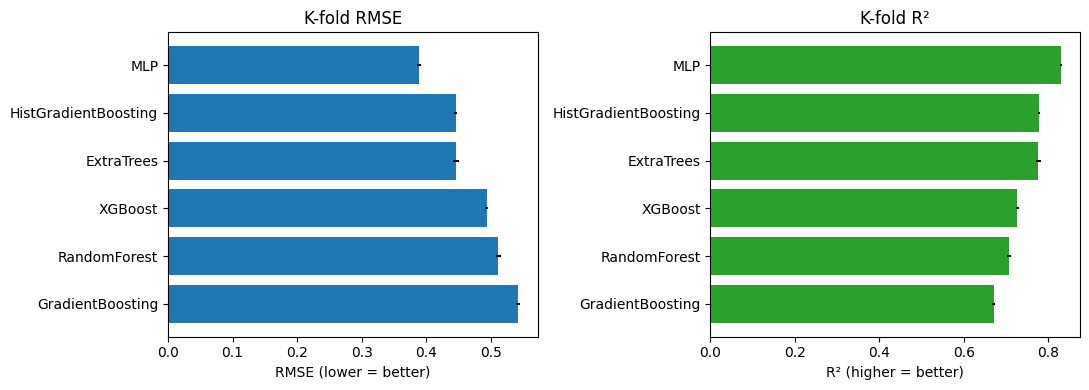

In [13]:
# Bar chart of model performance (matplotlib only — no plotly dependency)
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
m = metrics_df.sort_values('RMSE_mean')
axes[0].barh(m.index, m['RMSE_mean'], xerr=m['RMSE_std'])
axes[0].set_xlabel('RMSE (lower = better)'); axes[0].set_title('K-fold RMSE')
axes[0].invert_yaxis()
axes[1].barh(m.index, m['R2_mean'], xerr=m['R2_std'], color='C2')
axes[1].set_xlabel('R² (higher = better)'); axes[1].set_title('K-fold R²')
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()


## 7b. Predicted vs Observed scatter plots

For each model, runs `cross_val_predict` to get out-of-fold predictions on every training row, then plots Predicted vs Observed in a 2×N grid with R² and RMSE annotated per panel. The closer the points hug the y = x line, the better.


  predicting RandomForest ...
  predicting ExtraTrees ...
  predicting GradientBoosting ...
  predicting HistGradientBoosting ...
  predicting MLP ...
  predicting XGBoost ...


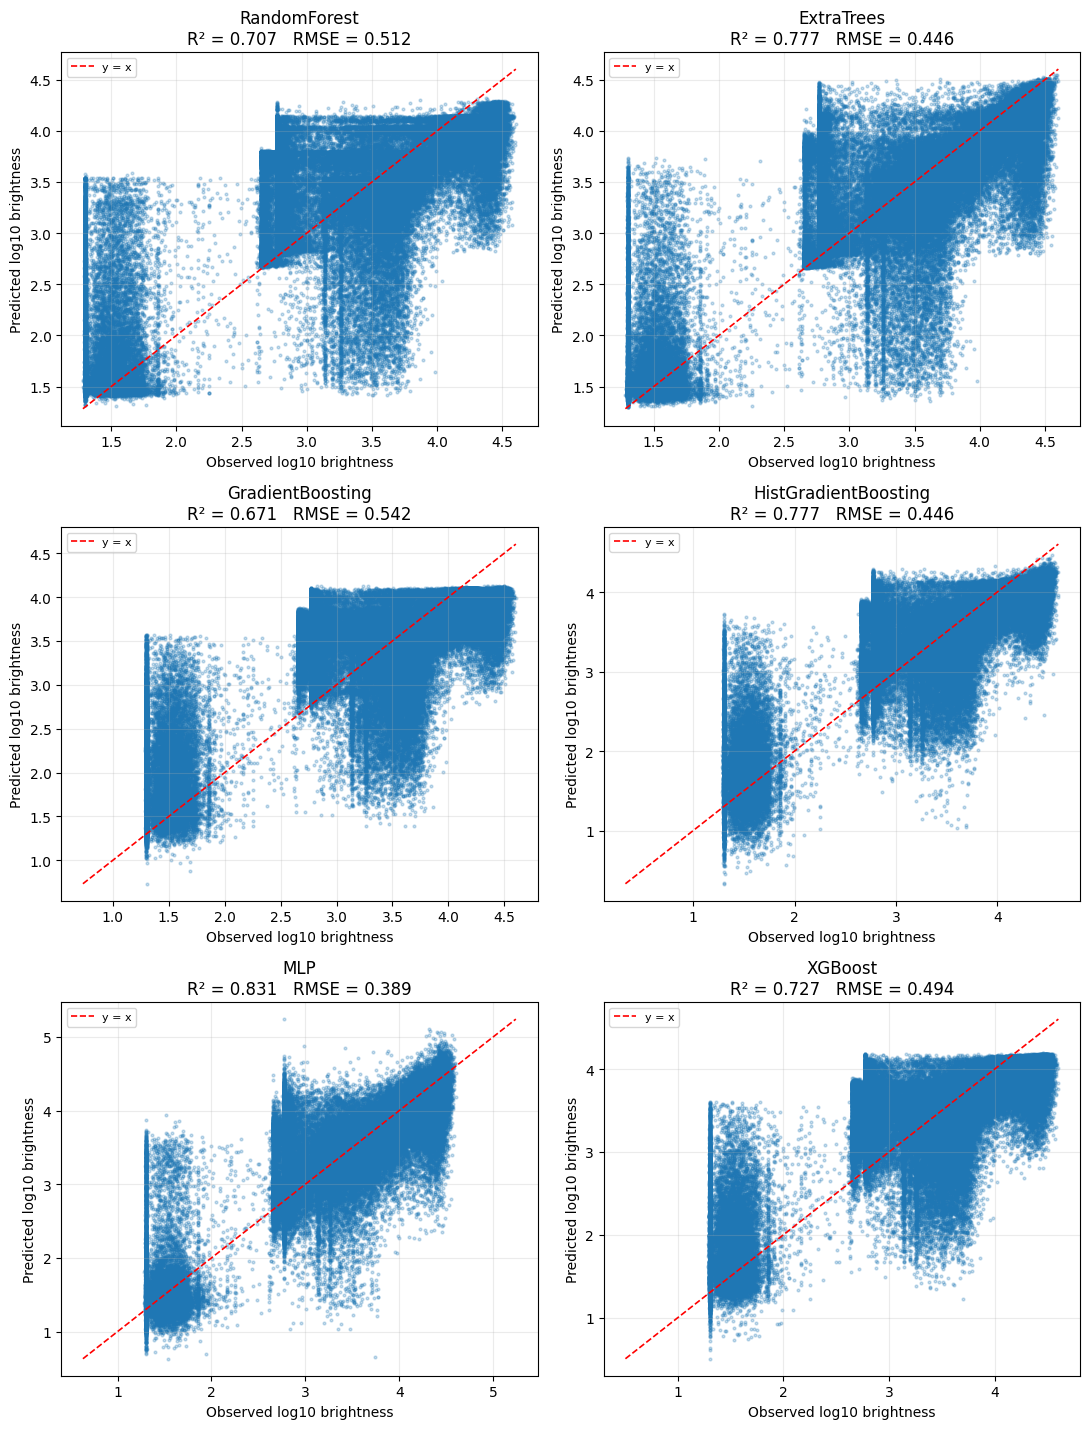

In [14]:
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt
import numpy as np

# Halve memory: tree models are unaffected by float32 vs float64.
Xcv = np.asarray(X, dtype=np.float32)

# Get out-of-fold predictions for each model using the same shuffled K-fold protocol.
cv_splitter = KFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)
cv_preds = {}
for name, mdl in models.items():
    print(f'  predicting {name} ...')
    # n_jobs=1: RF/ExtraTrees/HGB already multithread INTERNALLY. Outer
    # parallelism (n_jobs=-1) copies the full X into every worker process,
    # which is what exhausted RAM. One process = one copy of X.
    cv_preds[name] = cross_val_predict(mdl, Xcv, y, cv=cv_splitter, n_jobs=1)

# 2 columns x ceil(n/2) rows
names = list(cv_preds)
ncols = 2
nrows = (len(names) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.8 * nrows))
axes = np.atleast_1d(axes).ravel()  # robust for any nrows/ncols

for ax, name in zip(axes, names):
    yp = cv_preds[name]
    rmse = float(np.sqrt(mean_squared_error(y, yp)))
    r2 = float(r2_score(y, yp))
    ax.scatter(y, yp, s=4, alpha=0.25)
    lo, hi = min(y.min(), yp.min()), max(y.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.2, label='y = x')
    ax.set_xlabel('Observed log10 brightness')
    ax.set_ylabel('Predicted log10 brightness')
    ax.set_title(f'{name}\nR² = {r2:.3f}   RMSE = {rmse:.3f}')
    ax.grid(alpha=0.25)
    ax.legend(loc='upper left', fontsize=8)

# Hide any unused axes
for ax in axes[len(names):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### Residual plots (optional)

Residual = Observed − Predicted, plotted against the prediction. Flat-around-zero is good; a trend means the model is biased and may need different features or a transform.


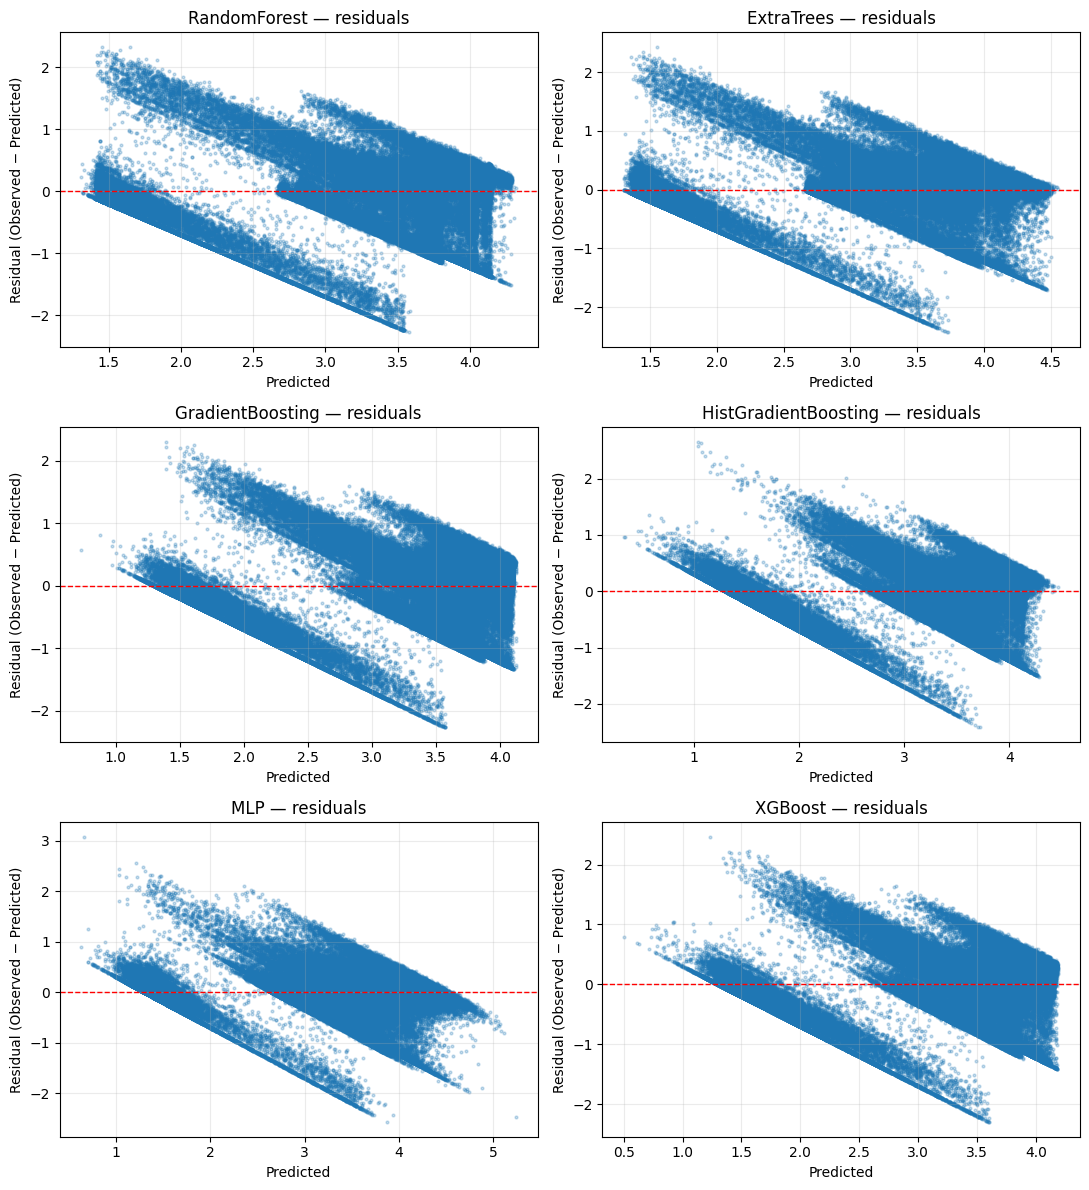

In [15]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.0 * nrows))
axes = axes.ravel() if nrows > 1 else [axes] if ncols == 1 else axes
for ax, name in zip(axes, names):
    yp = cv_preds[name]
    res = y - yp
    ax.scatter(yp, res, s=4, alpha=0.25)
    ax.axhline(0, color='r', ls='--', lw=1)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual (Observed − Predicted)')
    ax.set_title(f'{name} — residuals')
    ax.grid(alpha=0.25)
for ax in axes[len(names):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()


## 7c. Feature importance for each tree model (MDI)

Mean Decrease in Impurity is the built-in importance score for tree-based models. Higher = the feature is used more often or more decisively in the trees.


  fitting RandomForest on full training data ...
  fitting GradientBoosting on full training data ...
  fitting XGBoost on full training data ...


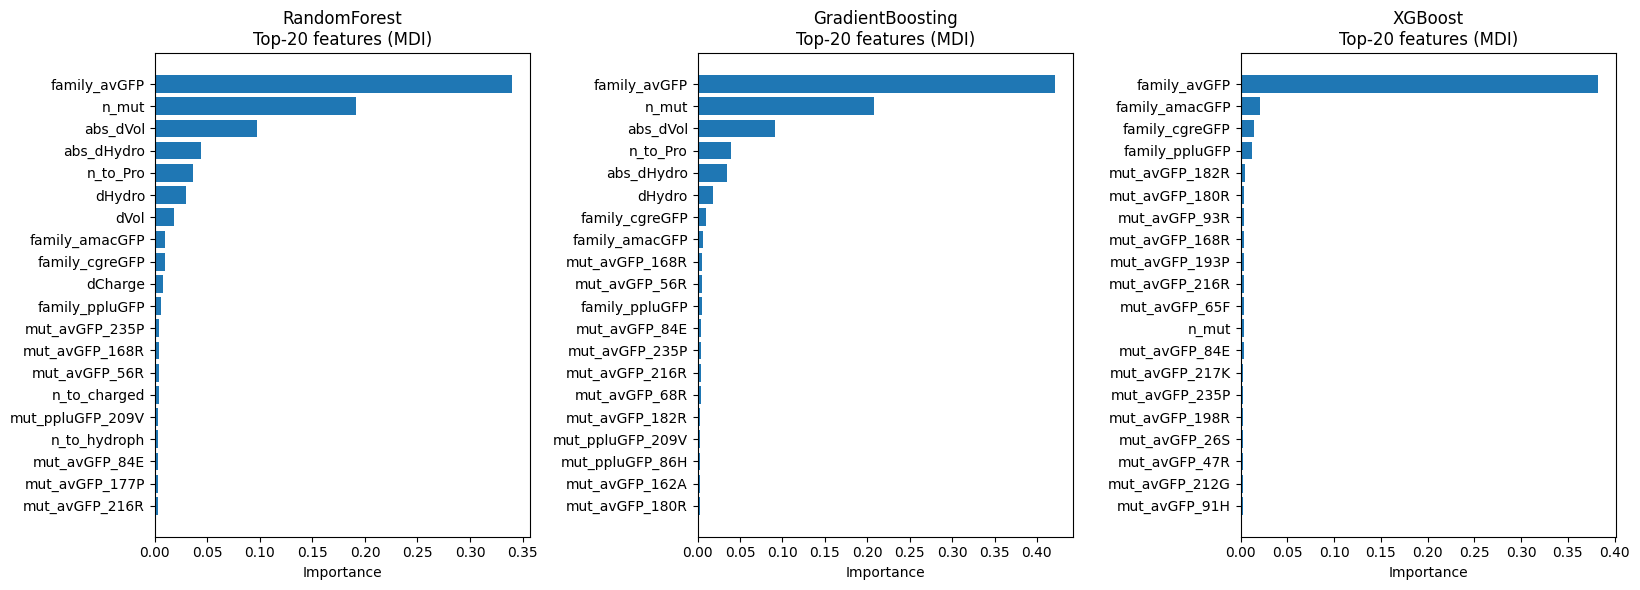

In [16]:
tree_models = {n: m for n, m in models.items()
               if hasattr(m, 'feature_importances_')
               or n in ('RandomForest', 'GradientBoosting', 'XGBoost')}

# Make sure each tree model has been fit on the full data
for n, m in tree_models.items():
    if not hasattr(m, 'feature_importances_'):
        print(f'  fitting {n} on full training data ...')
        m.fit(X, y)

fig, axes = plt.subplots(1, len(tree_models), figsize=(5.5 * len(tree_models), 6))
if len(tree_models) == 1: axes = [axes]

TOP = 20
for ax, (name, mdl) in zip(axes, tree_models.items()):
    imp = mdl.feature_importances_
    order = np.argsort(imp)[::-1][:TOP]
    names_top = [feat.feature_names[i] for i in order][::-1]
    vals_top = imp[order][::-1]
    ax.barh(names_top, vals_top)
    ax.set_title(f'{name}\nTop-{TOP} features (MDI)')
    ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# Tabular view of the top features for the best model
best_name_so_far = min(results, key=lambda n: results[n]['rmse_mean'])
if best_name_so_far in tree_models:
    imp = tree_models[best_name_so_far].feature_importances_
    top_df = pd.DataFrame({
        'feature': [feat.feature_names[i] for i in np.argsort(imp)[::-1][:25]],
        'importance': sorted(imp, reverse=True)[:25],
    })
    print(f'Top-25 features in {best_name_so_far}:')
    display(top_df)


## 7d. Explicit 80/20 train / test split

Single 80% / 20% split as a complement to the K-fold evaluation in section 7. Trains on the 80%, predicts on the held-out 20%, plots the comparison, and saves per-row predictions to `outputs_notebook/holdout_test_predictions.csv` for audit.


Train: 113,254 rows  |  Test: 28,314 rows  (20% held out)

=== Random held-out evaluation (MLP) ===
  RMSE = 0.387   R² = +0.834   on 28,314 unseen rows
  saved per-row predictions → C:\Users\Prawit\Desktop\My-Work\SynBio2026\ml_part\outputs_notebook\holdout_test_predictions.csv

=== Strict family-holdout validation (MLP) ===
  fold 1: hold out ['avGFP'] | n=51,714 | RMSE=1.148 | R²=-0.176
  fold 2: hold out ['amacGFP'] | n=33,808 | RMSE=1.782 | R²=-14.469
  fold 3: hold out ['ppluGFP'] | n=31,479 | RMSE=1.828 | R²=-11.513
  fold 4: hold out ['cgreGFP'] | n=24,567 | RMSE=1.630 | R²=-3.483
  mean RMSE=1.597±0.269; mean R²=-7.410±5.797
  saved strict validation report → C:\Users\Prawit\Desktop\My-Work\SynBio2026\ml_part\outputs_notebook\strict_family_holdout_report.json


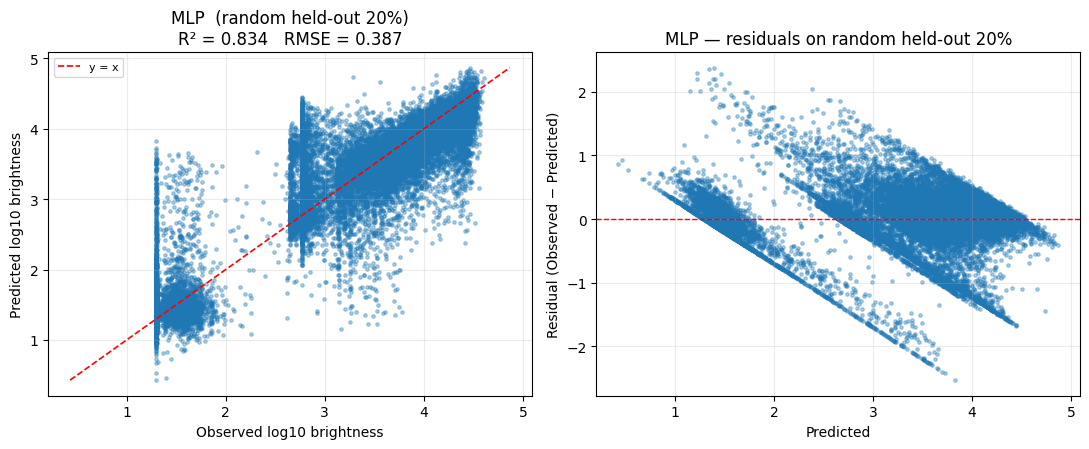

In [17]:
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone
import matplotlib.pyplot as plt
import numpy as np
import json

TEST_SIZE  = 0.20      # 20% test, 80% train
SPLIT_SEED = 42

# Use the same X, y, and best model the rest of the notebook produced
best_name = min(results, key=lambda n: results[n]['rmse_mean'])
model = clone(models[best_name])

# 80/20 random split. This is useful, but can still be optimistic for protein design.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SPLIT_SEED, shuffle=True)
print(f'Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows  '
      f'({100*TEST_SIZE:.0f}% held out)')

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
r2   = float(r2_score(y_test, y_pred))
print(f'\n=== Random held-out evaluation ({best_name}) ===')
print(f'  RMSE = {rmse:.3f}   R² = {r2:+.3f}   on {len(y_test):,} unseen rows')

# Save the per-row random-test predictions to disk so you can audit them later.
X_idx = np.arange(len(X))
_, te_idx, _, _ = train_test_split(
    X_idx, y, test_size=TEST_SIZE, random_state=SPLIT_SEED, shuffle=True)
test_aaMutations = df_use['aaMutations'].astype(str).iloc[te_idx].tolist()
test_family      = df_use['GFP type'].astype(str).iloc[te_idx].tolist() \
                   if 'GFP type' in df_use.columns else ['?']*len(te_idx)
test_preds = pd.DataFrame({
    'family':          test_family,
    'aaMutations':     test_aaMutations,
    'n_mutations':     [s.count(':')+1 if s and s != 'WT' else 0 for s in test_aaMutations],
    'observed_log10':  y_test,
    'predicted_log10': y_pred,
    'residual':        y_test - y_pred,
    'abs_residual':    np.abs(y_test - y_pred),
}).sort_values('abs_residual', ascending=False)
test_preds_path = OUT_DIR / 'holdout_test_predictions.csv'
test_preds.to_csv(test_preds_path, index=False)
print(f'  saved per-row predictions → {test_preds_path}')

# Stricter family-holdout validation for FAMILY='all'. This estimates whether the
# best model transfers across GFP families rather than memorizing family-specific patterns.
strict_validation = None
if DO_STRICT_FAMILY_HOLDOUT and 'GFP type' in df_use.columns:
    groups = df_use['GFP type'].astype(str).to_numpy()
    unique_groups = sorted(set(groups))
    if len(unique_groups) >= 2:
        n_splits = min(len(unique_groups), KFOLDS)
        gkf = GroupKFold(n_splits=n_splits)
        fold_rows = []
        print(f'\n=== Strict family-holdout validation ({best_name}) ===')
        for fold, (tr, te) in enumerate(gkf.split(X, y, groups=groups), 1):
            mdl = clone(models[best_name])
            mdl.fit(X[tr], y[tr])
            yp = mdl.predict(X[te])
            held_out = sorted(set(groups[te]))
            fold_rmse = float(np.sqrt(mean_squared_error(y[te], yp)))
            fold_r2 = float(r2_score(y[te], yp))
            fold_rows.append({
                'fold': fold,
                'held_out_family': '+'.join(held_out),
                'n_test': int(len(te)),
                'rmse': fold_rmse,
                'r2': fold_r2,
            })
            print(f'  fold {fold}: hold out {held_out} | n={len(te):,} | '
                  f'RMSE={fold_rmse:.3f} | R²={fold_r2:+.3f}')

        strict_df = pd.DataFrame(fold_rows)
        strict_validation = {
            'method': 'GroupKFold by GFP type',
            'n_splits': int(n_splits),
            'rmse_mean': float(strict_df['rmse'].mean()),
            'rmse_std': float(strict_df['rmse'].std(ddof=0)),
            'r2_mean': float(strict_df['r2'].mean()),
            'r2_std': float(strict_df['r2'].std(ddof=0)),
            'folds': fold_rows,
        }
        strict_path = OUT_DIR / 'strict_family_holdout_report.json'
        strict_path.write_text(json.dumps(strict_validation, indent=2))
        print(f'  mean RMSE={strict_validation["rmse_mean"]:.3f}±{strict_validation["rmse_std"]:.3f}; '
              f'mean R²={strict_validation["r2_mean"]:+.3f}±{strict_validation["r2_std"]:.3f}')
        print(f'  saved strict validation report → {strict_path}')
    else:
        print('\nStrict family-holdout skipped: fewer than two GFP families in the training set.')
else:
    print('\nStrict family-holdout skipped. Set FAMILY="all" and DO_STRICT_FAMILY_HOLDOUT=True to enable.')

# Predicted vs Observed scatter on the random held-out test set
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
ax = axes[0]
ax.scatter(y_test, y_pred, s=6, alpha=0.35)
lo, hi = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
ax.plot([lo, hi], [lo, hi], 'r--', lw=1.2, label='y = x')
ax.set_xlabel('Observed log10 brightness')
ax.set_ylabel('Predicted log10 brightness')
ax.set_title(f'{best_name}  (random held-out 20%)\nR² = {r2:.3f}   RMSE = {rmse:.3f}')
ax.grid(alpha=0.25); ax.legend(loc='upper left', fontsize=8)

# Residual plot
ax = axes[1]
ax.scatter(y_pred, y_test - y_pred, s=6, alpha=0.35)
ax.axhline(0, color='r', ls='--', lw=1)
ax.set_xlabel('Predicted'); ax.set_ylabel('Residual (Observed − Predicted)')
ax.set_title(f'{best_name} — residuals on random held-out 20%')
ax.grid(alpha=0.25)

plt.tight_layout(); plt.show()


## 8. (Optional) GridSearchCV for the best model

When `DO_GRIDSEARCH = True`, runs a small hyperparameter grid search on the winning model from section 7. Skip this in `'quick'` mode.


In [19]:
best_name = min(results, key=lambda n: results[n]['rmse_mean'])
print('Best model from CV:', best_name)

if DO_GRIDSEARCH:
    print('\nRunning grid search ...')

    # ------------------------------------------------------------------
    # Use a subsample of X for grid search to keep memory usage bounded.
    # Grid search only needs to find good hyperparameters, not fit the
    # final model — so 10K rows is plenty even if you trained on more.
    # ------------------------------------------------------------------
    GS_MAX_ROWS = 10_000
    if len(X) > GS_MAX_ROWS:
        rng_gs = np.random.RandomState(SEED)
        gs_idx = rng_gs.choice(len(X), size=GS_MAX_ROWS, replace=False)
        X_gs, y_gs = X[gs_idx], y[gs_idx]
        print(f'  (using {GS_MAX_ROWS:,}-row subsample for grid search to save RAM)')
    else:
        X_gs, y_gs = X, y

    if best_name == 'XGBoost':
        param_grid = {
            'n_estimators': [300, 500],
            'max_depth':    [6, 8],
            'learning_rate':[0.05, 0.08],
        }
        base = XGBRegressor(tree_method='hist', n_jobs=-1,
                            random_state=SEED, verbosity=0)

    elif best_name == 'GradientBoosting':
        param_grid = {
            'n_estimators': [200, 400],
            'max_depth':    [4, 5, 6],
            'learning_rate':[0.05, 0.08],
        }
        base = GradientBoostingRegressor(subsample=0.85, random_state=SEED)

    elif best_name == 'HistGradientBoosting':
        param_grid = {
            'max_iter':          [200, 400],
            'learning_rate':     [0.04, 0.07],
            'max_leaf_nodes':    [31, 63],
            'l2_regularization': [0.01, 0.05],
        }
        base = HistGradientBoostingRegressor(random_state=SEED)

    elif best_name == 'RandomForest':
        param_grid = {
            'n_estimators':     [200, 400],
            'max_depth':        [None, 20, 40],
            'min_samples_leaf': [2, 4, 8],
        }
        base = RandomForestRegressor(n_jobs=-1, random_state=SEED)

    elif best_name == 'ExtraTrees':
        param_grid = {
            'n_estimators':     [200, 400],
            'max_features':     [0.5, 0.7, 0.9],
            'min_samples_leaf': [1, 2, 4],
        }
        base = ExtraTreesRegressor(n_jobs=-1, random_state=SEED)

    else:  # MLP
        param_grid = {
            'mlp__hidden_layer_sizes': [(64, 32), (128, 64), (32, 16)],
            'mlp__alpha':              [1e-4, 1e-3],
        }
        base = Pipeline([
            ('scale', StandardScaler(with_mean=False)),
            ('mlp',   MLPRegressor(activation='relu', solver='adam',
                                   max_iter=100, early_stopping=True,
                                   random_state=SEED))
        ])

    gs = GridSearchCV(
        base, param_grid,
        cv=3,                               # 3-fold is enough for hyperparam selection
        scoring='neg_root_mean_squared_error',
        n_jobs=1,                           # serial: avoids RAM × n_workers explosion
        verbose=1,
        refit=True,                         # refit best params on full X_gs after search
    )
    gs.fit(X_gs, y_gs)
    print('Best params:', gs.best_params_)
    print(f'Best CV RMSE (on {len(X_gs):,}-row subsample): {-gs.best_score_:.4f}')

    # Refit the best estimator on the FULL X so the saved model uses all data
    best_model = clone(gs.best_estimator_)
    best_model.set_params(**gs.best_params_)
    print('\nRefitting best params on full training set ...')
    best_model.fit(X, y)
    print('Done.')

else:
    # clone() is critical here — without it best_model is a reference to
    # models[best_name], so the subsequent .fit(X, y) in the next cell
    # would silently mutate the original model inside the models dict.
    best_model = clone(models[best_name])
    print('(Skipping grid search; using default hyperparameters)')

Best model from CV: MLP

Running grid search ...
  (using 10,000-row subsample for grid search to save RAM)
Fitting 3 folds for each of 6 candidates, totalling 18 fits


c:\Users\Prawit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Prawit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Prawit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Prawit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the 

Best params: {'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (32, 16)}
Best CV RMSE (on 10,000-row subsample): 0.7522

Refitting best params on full training set ...
Done.


In [20]:
# Refit best model on the full dataset and save
try:
    import cloudpickle as pickle
except Exception:
    import pickle
best_model.fit(X, y)
bundle = {
    'model':                      best_model,
    'featurizer':                 feat,
    'model_name':                 best_name,
    'wt_brightness':              wt_brightness,
    'training_family_setting':    FAMILY,
    'candidate_family_for_model': CANDIDATE_FAMILY_FOR_MODEL,
    'use_family_features':        bool(USE_FAMILY),
    'cv_results':                 results,
    'strict_validation':          strict_validation if 'strict_validation' in globals() else None,
}
model_path = OUT_DIR / 'best_model.pkl'
with model_path.open('wb') as f:
    pickle.dump(bundle, f)
print(f'Saved → {model_path}  ({model_path.stat().st_size/1e6:.2f} MB)')

import json
(OUT_DIR / 'ml_cv_report.json').write_text(json.dumps(
    {'training_family_setting': FAMILY,
     'candidate_family_for_model': CANDIDATE_FAMILY_FOR_MODEL,
     'n_samples': int(len(y)), 'wt_brightness': wt_brightness,
     'feature_dim': int(X.shape[1]), 'k': KFOLDS, 'best_model': best_name,
     'random_kfold_models': results,
     'strict_validation': strict_validation if 'strict_validation' in globals() else None}, indent=2))
print(f'Saved → {OUT_DIR / "ml_cv_report.json"}')


Saved → C:\Users\Prawit\Desktop\My-Work\SynBio2026\ml_part\outputs_notebook\best_model.pkl  (0.91 MB)
Saved → C:\Users\Prawit\Desktop\My-Work\SynBio2026\ml_part\outputs_notebook\ml_cv_report.json


## 8b. Dual-model training (handles bimodal brightness data)

The avGFP brightness data is bimodal — about 22% of rows are clipped at the detection floor (~1.30) and ~58% sit in the bright cluster (≥ 2.5). To address this, we train two models on the same featurization with the winning algorithm:

- `all_data_model` — every row, used for the "is this dead?" signal
- `bright_focused_model` — only rows with brightness ≥ 2.5

At inference time we ensemble: `pred = 0.6 · bright + 0.4 · all_data`.


In [21]:
from sklearn.base import clone

BRIGHT_THRESHOLD = 2.5
bright_mask = y >= BRIGHT_THRESHOLD
n_bright = int(bright_mask.sum())
print(f'bright rows (brightness >= {BRIGHT_THRESHOLD}): '
      f'{n_bright:,}/{len(y):,} ({100*n_bright/len(y):.1f}%)')

all_model = clone(models[best_name])
all_model.fit(X, y)

bright_model = clone(models[best_name])
bright_model.fit(X[bright_mask], y[bright_mask])

# CV the bright-focused model independently
k_bright = min(KFOLDS, max(2, n_bright // 500))
cv_bright = kfold_cv(clone(models[best_name]), X[bright_mask], y[bright_mask],
                      k=k_bright)
print(f'bright-focused CV ({k_bright}-fold): '
      f'RMSE={cv_bright["rmse_mean"]:.3f}  R²={cv_bright["r2_mean"]:+.3f}')

# Save dual bundle (overwrites the single-model bundle from section 8)
try:
    import cloudpickle as pickle
except Exception:
    import pickle
dual_bundle = {
    'model':                      all_model,            # legacy alias
    'all_data_model':             all_model,
    'bright_focused_model':       bright_model,
    'bright_threshold':           BRIGHT_THRESHOLD,
    'featurizer':                 feat,
    'model_name':                 best_name,
    'wt_brightness':              wt_brightness,
    'training_family_setting':    FAMILY,
    'candidate_family_for_model': CANDIDATE_FAMILY_FOR_MODEL,
    'use_family_features':        bool(USE_FAMILY),
    'cv_results':                 results,
    'bright_focused_cv':          cv_bright,
    'strict_validation':          strict_validation if 'strict_validation' in globals() else None,
}
model_path = OUT_DIR / 'best_model.pkl'
with model_path.open('wb') as f:
    pickle.dump(dual_bundle, f)
print(f'Saved dual-model bundle → {model_path}  ({model_path.stat().st_size/1e6:.2f} MB)')

# Quick ensemble-prediction demo (60% bright + 40% all)
def ensemble_predict(X):
    return 0.6 * bright_model.predict(X) + 0.4 * all_model.predict(X)

# Compare on a random 1000 rows
import numpy as np
idx_demo = np.random.RandomState(SEED).choice(len(X), size=min(1000, len(X)), replace=False)
yp_dual = ensemble_predict(X[idx_demo])
yp_single = all_model.predict(X[idx_demo])
from sklearn.metrics import mean_squared_error, r2_score
print(f'\nOn a random 1000-row sample (sanity, NOT held-out):')
print(f'  single all-data:  RMSE={np.sqrt(mean_squared_error(y[idx_demo], yp_single)):.3f}  '
      f'R²={r2_score(y[idx_demo], yp_single):+.3f}')
print(f'  dual-model ens:   RMSE={np.sqrt(mean_squared_error(y[idx_demo], yp_dual)):.3f}  '
      f'R²={r2_score(y[idx_demo], yp_dual):+.3f}')


bright rows (brightness >= 2.5): 119,940/141,568 (84.7%)
bright-focused CV (10-fold): RMSE=0.331  R²=+0.602
Saved dual-model bundle → C:\Users\Prawit\Desktop\My-Work\SynBio2026\ml_part\outputs_notebook\best_model.pkl  (4.94 MB)

On a random 1000-row sample (sanity, NOT held-out):
  single all-data:  RMSE=0.230  R²=+0.944
  dual-model ens:   RMSE=0.475  R²=+0.761


## 9. (Optional) SHAP feature importance

SHAP shows which features the model relies on most for its predictions.


In [22]:
try:
    import shap
    bg = X[np.random.RandomState(SEED).choice(len(X), size=100, replace=False)]
    expl = shap.TreeExplainer(best_model, data=bg)
    sample = X[np.random.RandomState(SEED+1).choice(len(X), size=200, replace=False)]
    sv = expl.shap_values(sample)
    mean_abs = np.abs(sv).mean(axis=0)
    order = np.argsort(mean_abs)[::-1][:25]
    top_df = pd.DataFrame({
        'feature':    [feat.feature_names[i] for i in order],
        'mean_|SHAP|': mean_abs[order]
    })
    print('Top-25 most important features:')
    display(top_df)
    shap.summary_plot(sv, sample, feature_names=feat.feature_names, max_display=20)
except Exception as e:
    print('SHAP analysis skipped:', e)


SHAP analysis skipped: No module named 'shap'


## 10. Build the design pipeline

Construct the mutation pools used to generate candidate sequences:

- **Thermostability candidates** — 16 literature-validated mutations from sfGFP, superfolder, TGP, mClover3, etc. No Cys (the cell-free system is reducing).
- **Brightness candidates** — top per-position substitutions from the data, filtered for functional retention rate ≥ 50% and best-case Δlog₁₀ ≥ 0.05.


In [23]:
# Thermostability candidates (positions in canonical 238-aa numbering, post-2026-05-27 correction)
def make_thermo_candidates():
    raw = [
        # (canonical_pos, target_aa, weight, source)
        (206,'K',0.95,'A206K monomerizing'),
        (167,'T',0.85,'I167T folding'),
        (149,'K',0.65,'surface charge'),
        (147,'T',0.55,'surface stabilizing'),
        (177,'F',0.55,'TGP-inspired core packing'),
        (223,'I',0.60,'TGP barrel packing'),
        (224,'L',0.55,'TGP barrel packing'),
        (46, 'L',0.50,'F46L loop'),
        (80, 'R',0.50,'Q80R surface'),
        (231,'L',0.45,'T231L barrel (note: canonical pos 231 is H in sfGFP — see code review)'),
        (78, 'K',0.40,'Q78K surface'),
        (176,'K',0.40,'N176K surface'),
        (154,'L',0.45,'TGP-like core'),
        (43, 'L',0.35,'F43L loop'),
        (141,'L',0.30,'I141L barrel'),
        (195,'I',0.30,'V195I core'),
    ]
    # canon_to_comp is identity post-correction; chromophore guard remains.
    return [(canon_to_comp(p), a, w) for p, a, w, _ in raw
            if (canon_to_comp(p) - 1) not in CHROMO_POS_0IDX]

# Brightness candidates from data (top per-position substitutions).
# IMPORTANT FIX: if FAMILY='all', extract position-level brightness effects only
# from CANDIDATE_FAMILY_FOR_MODEL (default avGFP). This avoids mixing distant GFP
# family numbering/effects into the sfGFP design scaffold.
def make_brightness_candidates(df_use_full, mutation_sets, y, families=None,
                               candidate_family=CANDIDATE_FAMILY_FOR_MODEL,
                               top_k=2, min_func_rate=0.5,
                               min_support=5, min_effect=0.05):
    """Top mutations per position with positive top-quartile effect and high functional retention."""
    from collections import defaultdict

    if families is None:
        families = ['?'] * len(mutation_sets)

    bucket = defaultdict(list)
    used_rows = 0
    for muts, b, fam in zip(mutation_sets, y, families):
        if candidate_family is not None and str(fam) != str(candidate_family):
            continue
        used_rows += 1
        for ref, pos, alt in muts:
            bucket[(pos, alt)].append(float(b))

    if used_rows == 0:
        raise ValueError(
            f'No rows found for candidate_family={candidate_family!r}. '
            'Change CANDIDATE_FAMILY_FOR_MODEL or train with FAMILY="avGFP".'
        )

    table = {}
    for key, vals in bucket.items():
        if len(vals) < min_support:
            continue
        vs = sorted(vals, reverse=True)
        top_q = vs[:max(1, len(vs)//4)]
        top_mean = sum(top_q)/len(top_q)
        func = sum(1 for v in vals if v >= 2.5)/len(vals)
        if func < min_func_rate:
            continue
        table[key] = {'effect': top_mean - wt_brightness, 'func_rate': func}

    # Pick top_k per position with effect >= min_effect, no Cys
    per_pos = defaultdict(list)
    for (pos, aa), v in table.items():
        if aa == 'C':
            continue
        if v['effect'] < min_effect:
            continue
        per_pos[pos].append((aa, v['effect']))

    pool = []
    for pos, items in per_pos.items():
        items.sort(key=lambda t: -t[1])
        for aa, eff in items[:top_k]:
            comp_pos = canon_to_comp(pos)
            if (comp_pos - 1) in CHROMO_POS_0IDX:
                continue
            pool.append((comp_pos, aa, eff))
    return pool, used_rows

thermo_pool = make_thermo_candidates()
bright_pool, n_bright_source_rows = make_brightness_candidates(
    df_use, mutation_sets, y, families=families,
    candidate_family=CANDIDATE_FAMILY_FOR_MODEL
)
print(f'Thermo pool:    {len(thermo_pool)} candidates')
print(f'Brightness pool: {len(bright_pool)} candidates '
      f'(from {n_bright_source_rows:,} {CANDIDATE_FAMILY_FOR_MODEL} rows)')

# Merge, dedup by (pos, aa), keep highest weight
seen = {}
for pos, aa, w in thermo_pool + bright_pool:
    key = (pos, aa)
    if key not in seen or w > seen[key][2]:
        seen[key] = (pos, aa, w)
merged_pool = list(seen.values())
print(f'Merged pool:    {len(merged_pool)} unique (pos, aa) candidates')


Thermo pool:    16 candidates
Brightness pool: 66 candidates (from 51,714 avGFP rows)
Merged pool:    82 unique (pos, aa) candidates


## 11. Generate the candidate library

Random combinatorial sampling of mutations from the merged pool, applied to the sfGFP scaffold. Always includes WT for reference.


In [24]:
import random

def apply_mutations(parent, muts):
    s = list(parent)
    for pos, aa in muts:
        i = pos - 1
        if 0 <= i < len(s): s[i] = aa
    return ''.join(s)

def random_combos(parent, pool, n, size_range=(2, 8), seed=SEED):
    rng = random.Random(seed)
    out = set()
    attempts = 0
    while len(out) < n and attempts < n * 50:
        attempts += 1
        k = rng.randint(*size_range)
        k = min(k, len(pool))
        combo = rng.sample(pool, k)
        by_pos = {}
        for pos, aa in combo:
            by_pos[pos] = aa
        out.add(apply_mutations(parent, list(by_pos.items())))
    return list(out)

# Use sfGFP_238 (canonical, post-2026-05-27 correction) as primary parent (competition WT).
pool_sfgfp = [(p, a) for p, a, _ in merged_pool]
candidates = random_combos(SFGFP, pool_sfgfp, n=N_CANDIDATES, seed=SEED)
candidates = [SFGFP] + candidates  # always include WT for reference
print(f'Generated {len(candidates):,} candidate sequences')


Generated 10,001 candidate sequences


## 12. Hard filters: validity + exclusion list

Three competition rules:

- length 220–250 aa, starts with M, only standard 20 amino acids, no stop codons
- not present in `Exclusion_List.csv` (135 414 forbidden sequences)


In [25]:
import hashlib  # auto-added (was missing in this cell)
def valid(seq):
    if not isinstance(seq, str): return False
    if not (MIN_LEN <= len(seq) <= MAX_LEN): return False
    if seq[0] != 'M': return False
    if set(seq) - AA_SET: return False
    if '*' in seq: return False
    return True

before = len(candidates)
candidates = [s for s in candidates if valid(s)]
print(f'After validity filter: {len(candidates):,} (removed {before-len(candidates):,})')

# Exclusion-list filter (hash-based for O(1) lookup)
import csv, hashlib
print('Loading exclusion list ...')
excl = set()
with paths['exclusion'].open() as f:
    r = csv.reader(f); next(r, None)
    for row in r:
        if row and row[0].strip():
            excl.add(hashlib.sha256(row[0].strip().upper().encode()).hexdigest())
print(f'  {len(excl):,} excluded sequences loaded')

before = len(candidates)
candidates = [s for s in candidates
              if hashlib.sha256(s.strip().upper().encode()).hexdigest() not in excl]
print(f'After exclusion filter: {len(candidates):,} (removed {before-len(candidates):,})')


After validity filter: 10,001 (removed 0)
Loading exclusion list ...
  135,414 excluded sequences loaded
After exclusion filter: 9,999 (removed 2)


## 13. Score every candidate with the ML model + thermostability prior

Composite score = `0.6 · normalized(ML brightness) + 0.4 · normalized(thermostability prior)`. Tunable via `W_ML` and `W_THERMO` in this cell.


In [26]:
# Convert sequences → mutation sets relative to canonical sfGFP_238 → features → ML predictions
# Post-2026-05-27 correction: no position shift is needed for the 238-aa parent.
# The legacy 239-aa branch is preserved only as a no-op guard in case any old
# 239-aa data is fed in.
def seq_to_mut_set(seq, parent=SFGFP):
    if len(seq) != len(parent): return []
    out = []
    is_239_legacy = (len(parent) == 239)  # only true for the OLD erroneous parent
    for pos, (a, b) in enumerate(zip(parent, seq), 1):
        if a == b: continue
        if is_239_legacy:
            if pos <= 171:    canon = pos
            elif pos == 172:  continue
            else:             canon = pos - 1
        else:
            canon = pos  # canonical 238-aa parent → no shift
        out.append((a, canon, b))
    return out

cand_mut_sets = [seq_to_mut_set(s) for s in candidates]

# FAMILY='all' fix:
# The featurizer was trained with family labels, so scoring must pass a family
# label for all candidate sequences. sfGFP is avGFP-derived, so use avGFP as the
# candidate-family proxy unless you intentionally change the config.
candidate_families = [CANDIDATE_FAMILY_FOR_MODEL] * len(cand_mut_sets)
X_cand = feat.transform(
    cand_mut_sets,
    families=candidate_families if getattr(feat, 'use_family', USE_FAMILY) else None
)

# Use the best available model: dual-model ensemble first, then
# single best_model, then fall back to the best by RMSE from the model zoo.
if 'all_model' in dir() and 'bright_model' in dir():
    ml_scores = 0.6 * bright_model.predict(X_cand) + 0.4 * all_model.predict(X_cand)
elif 'best_model' in dir():
    ml_scores = best_model.predict(X_cand)
else:
    # No model trained yet — pick the lowest-RMSE from section 7 and fit on full data
    best_name = min(results, key=lambda n: results[n]['rmse_mean'])
    from sklearn.base import clone
    fallback_model = clone(models[best_name])
    fallback_model.fit(X, y)
    ml_scores = fallback_model.predict(X_cand)
    print(f'  (auto-fit {best_name} since no saved model found)')
print(f'ML predictions:  range=[{ml_scores.min():.2f}, {ml_scores.max():.2f}]')

# Thermostability prior (sum of literature weights for matched mutations)
thermo_lookup = {(p, a): w for p, a, w in thermo_pool}
def thermo_score(seq):
    if len(seq) != len(SFGFP): return 0.0
    s = 0.0
    for i, (a, b) in enumerate(zip(SFGFP, seq), 1):
        if a == b: continue
        w = thermo_lookup.get((i, b))
        if w is not None: s += w
        else: s -= 0.05  # small drift penalty
    return s

thermo_scores = np.array([thermo_score(s) for s in candidates], dtype=np.float32)
print(f'Thermo scores:   range=[{thermo_scores.min():.2f}, {thermo_scores.max():.2f}]')

# Composite surrogate score.
# NOTE: This is NOT the real competition score. The real assay score is:
# relative brightness × post-72°C fluorescence-retention ratio.
# This surrogate is only used to rank in-silico candidates before structural checks.
def normalize(v):
    lo, hi = v.min(), v.max()
    return (v - lo) / (hi - lo + 1e-9)

W_ML, W_THERMO = 0.6, 0.4
composite = W_ML * normalize(ml_scores) + W_THERMO * normalize(thermo_scores)
print(f'Composite surrogate range: [{composite.min():.3f}, {composite.max():.3f}]')


ML predictions:  range=[2.33, 4.23]
Thermo scores:   range=[-0.40, 3.00]
Composite surrogate range: [0.028, 0.784]


## 14. Pick the diverse Top 6

Greedy selection: highest composite score first, then enforce Hamming distance ≥ 4 to all already-picked sequences. Skips the WT reference.


In [27]:
def hamming(a, b):
    return sum(1 for x, y in zip(a, b) if x != y) + abs(len(a) - len(b))

# Sort by composite surrogate score, then greedy pick with Hamming-distance diversity.
# Skip candidates with 0 mutations (they're the parent itself — not a design).
order = np.argsort(-composite)
picks_idx = []
MIN_HAMMING = 4
MIN_MUTATIONS = 1   # require at least 1 mutation vs parent
MAX_MUTATIONS = 6   # cap mutations to keep designs conservative
for i in order:
    if len(picks_idx) >= 6: break
    cand_seq = candidates[i]
    n_mut = sum(1 for a, b in zip(SFGFP, cand_seq) if a != b)
    if n_mut < MIN_MUTATIONS or n_mut > MAX_MUTATIONS:
        continue   # skip WT, near-WT, or over-engineered
    if all(hamming(cand_seq, candidates[j]) >= MIN_HAMMING for j in picks_idx):
        picks_idx.append(int(i))

if len(picks_idx) < 6:
    raise RuntimeError(
        f'Only selected {len(picks_idx)} sequences. '
        'Increase N_CANDIDATES, relax MIN_HAMMING, or raise MAX_MUTATIONS.'
    )

# Build picks DataFrame for inspection
rows = []
for rank, i in enumerate(picks_idx, 1):
    seq = candidates[i]
    muts = [f'{a}{p}{b}' for (a,p,b) in seq_to_mut_set(seq)]
    rows.append({
        'rank':       rank,
        'n_mut':      len(muts),
        'ml_pred':    float(ml_scores[i]),
        'thermo':     float(thermo_scores[i]),
        'composite':  float(composite[i]),
        'mutations':  ','.join(muts),
        'sequence':   seq,
    })
picks_df = pd.DataFrame(rows)
display(picks_df.drop(columns=['sequence']))


,rank,n_mut,ml_pred,thermo,composite,mutations
0,1,5,4.119843,1.45,0.784344,"T38N,G104Y,G116E,N149K,V206K"
1,2,4,3.874442,1.70,0.736167,"G104Y,I167T,Q204T,V206K"
2,3,4,3.593599,1.75,0.653253,"T38N,M78K,V206K,H231L"
3,4,6,3.920864,0.85,0.650844,"T38N,G116E,N149K,G174T,V176K,Q204T"
4,5,4,3.616010,1.65,0.648574,"T38N,F46L,N149K,V224L"
5,6,6,4.163881,0.15,0.645327,"L18N,T38N,M78K,G104Y,G116E,N170V"


## 15. Final validation & write submission

Independent re-validation against every competition rule, then writes `outputs_notebook/submission.csv` in the official three-column format.


In [28]:
import hashlib  # auto-added (was missing in this cell)
# Independent re-validation
final_seqs = picks_df['sequence'].tolist()
assert len(final_seqs) == 6, 'Expected 6 sequences'
for i, s in enumerate(final_seqs, 1):
    assert valid(s), f'Sequence {i} failed validation'
    assert len(s) == len(SFGFP), f'Sequence {i} length differs from sfGFP parent'
    assert s[0] == 'M', f'Sequence {i} does not start with M'
    assert not any((idx in CHROMO_POS_0IDX) and (s[idx] != SFGFP[idx])
                   for idx in range(len(SFGFP))), f'Sequence {i} mutates the chromophore region'
    h = hashlib.sha256(s.strip().upper().encode()).hexdigest()
    assert h not in excl, f'Sequence {i} is in the exclusion list!'
print('[OK] all 6 sequences pass validation, preserve chromophore residues, and are not in the exclusion list')

# Verify pairwise diversity
print('\nPairwise Hamming distances:')
for i in range(6):
    for j in range(i+1, 6):
        print(f'  [{i+1}] vs [{j+1}]: {hamming(final_seqs[i], final_seqs[j])}')

# Write submission CSV in the official format
sub_path = OUT_DIR / 'submission.csv'
with sub_path.open('w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['Team_Name', 'Seq_ID', 'Sequence'])
    for i, s in enumerate(final_seqs, 1):
        w.writerow([TEAM_NAME, i, s])
print(f'\nWrote submission → {sub_path}')

# Verify header matches the official template byte-for-byte
import csv as _csv
with paths['template'].open() as f:
    tpl_header = next(_csv.reader(f))
with sub_path.open() as f:
    sub_header = next(_csv.reader(f))
assert sub_header == tpl_header, f'Header mismatch: {sub_header} vs {tpl_header}'
print('[OK] header matches submission_template.csv exactly')


[OK] all 6 sequences pass validation, preserve chromophore residues, and are not in the exclusion list

Pairwise Hamming distances:
  [1] vs [2]: 5
  [1] vs [3]: 5
  [1] vs [4]: 5
  [1] vs [5]: 5
  [1] vs [6]: 5
  [2] vs [3]: 6
  [2] vs [4]: 8
  [2] vs [5]: 8
  [2] vs [6]: 8
  [3] vs [4]: 8
  [3] vs [5]: 6
  [3] vs [6]: 6
  [4] vs [5]: 6
  [4] vs [6]: 8
  [5] vs [6]: 8

Wrote submission → C:\Users\Prawit\Desktop\My-Work\SynBio2026\ml_part\outputs_notebook\submission.csv
[OK] header matches submission_template.csv exactly


In [29]:
import json  # auto-added (was missing in this cell)
# Write design log with full provenance
design_log = {
    'meta': {
        'team_name':                  TEAM_NAME,
        'run_mode':                   RUN_MODE,
        'seed':                       SEED,
        'n_candidates':               N_CANDIDATES,
        'training_family_setting':    FAMILY,
        'candidate_family_for_model': CANDIDATE_FAMILY_FOR_MODEL,
        'best_ml_model':              best_name,
        'ml_cv_rmse':                 results[best_name]['rmse_mean'],
        'ml_cv_r2':                   results[best_name]['r2_mean'],
        'strict_validation':          strict_validation if 'strict_validation' in globals() else None,
        'weights':                    {'ml': W_ML, 'thermo': W_THERMO},
        'score_note':                 (
            'composite_score is an in-silico surrogate only. '
            'The real competition score is relative brightness × thermal-retention ratio.'
        ),
    },
    'designs': [],
}
for r in rows:
    design_log['designs'].append({
        'seq_id':                r['rank'],
        'n_mutations':           r['n_mut'],
        'mutations':             r['mutations'].split(',') if r['mutations'] else [],
        'ml_brightness_log10':   round(r['ml_pred'], 4),
        'thermostability_prior': round(r['thermo'], 4),
        'composite_score':       round(r['composite'], 4),
        'sequence':              r['sequence'],
    })
log_path = OUT_DIR / 'design_log.json'
log_path.write_text(json.dumps(design_log, indent=2))
print(f'Wrote design log → {log_path}')


Wrote design log → C:\Users\Prawit\Desktop\My-Work\SynBio2026\ml_part\outputs_notebook\design_log.json


## 16. Where the outputs are

All output files land in `outputs_notebook/` and are visible in the VS Code file explorer right after the cells finish.


In [30]:
print(f'Output folder: {OUT_DIR}\n')
for f in sorted(OUT_DIR.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size/1e3:.1f} KB)')

print()
print('Key files:')
print(f'  submission.csv                    → official submission for the competition portal')
print(f'  design_log.json                   → per-sequence provenance for the Design Concept Document')
print(f'  ml_cv_report.json                 → random K-fold metrics and strict-validation metadata')
print(f'  strict_family_holdout_report.json → optional family-holdout validation report, if enabled')
print(f'  best_model.pkl                    → trained model bundle (pickle)')

# Reveal the folder in Finder / File Explorer (best-effort, OS-dependent)
import sys, subprocess
try:
    if sys.platform == 'darwin':
        subprocess.run(['open', str(OUT_DIR)], check=False)
    elif sys.platform.startswith('win'):
        subprocess.run(['explorer', str(OUT_DIR)], check=False)
    elif sys.platform.startswith('linux'):
        subprocess.run(['xdg-open', str(OUT_DIR)], check=False)
except Exception as e:
    print(f'(Could not open the folder automatically: {e})')


Output folder: C:\Users\Prawit\Desktop\My-Work\SynBio2026\ml_part\outputs_notebook

  best_model.pkl  (4940.7 KB)
  design_log.json  (4.9 KB)
  holdout_test_predictions.csv  (1987.4 KB)
  ml_cv_report.json  (6.5 KB)
  strict_family_holdout_report.json  (0.9 KB)
  submission.csv  (1.5 KB)

Key files:
  submission.csv                    → official submission for the competition portal
  design_log.json                   → per-sequence provenance for the Design Concept Document
  ml_cv_report.json                 → random K-fold metrics and strict-validation metadata
  strict_family_holdout_report.json → optional family-holdout validation report, if enabled
  best_model.pkl                    → trained model bundle (pickle)


## 17. What to do next

**Tuning to improve ranking:**

- Set `RUN_MODE = 'full'` in cell 4 — trains on all rows of the chosen family.
- Set `FAMILY = 'all'` to use all four GFP families (~141k rows total).
- Set `DO_GRIDSEARCH = True` and re-run.
- Adjust `W_ML` vs `W_THERMO` in section 13 to bias toward brightness or thermostability.
- Add ESM-2 features by encoding sequences with `facebook/esm2_t6_8M_UR50D` and concatenating to the engineered features.

**Before submitting:**

1. Set `TEAM_NAME` to your real team name.
2. Run with `RUN_MODE = 'full'` and `DO_GRIDSEARCH = True`.
3. Re-run sections 14 and 15 to regenerate the submission.
4. Open `outputs_notebook/submission.csv` to confirm UTF-8 / Unix line endings.
5. Push your code to GitHub (public repo with this notebook).
